In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from corrosion1d.configs import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




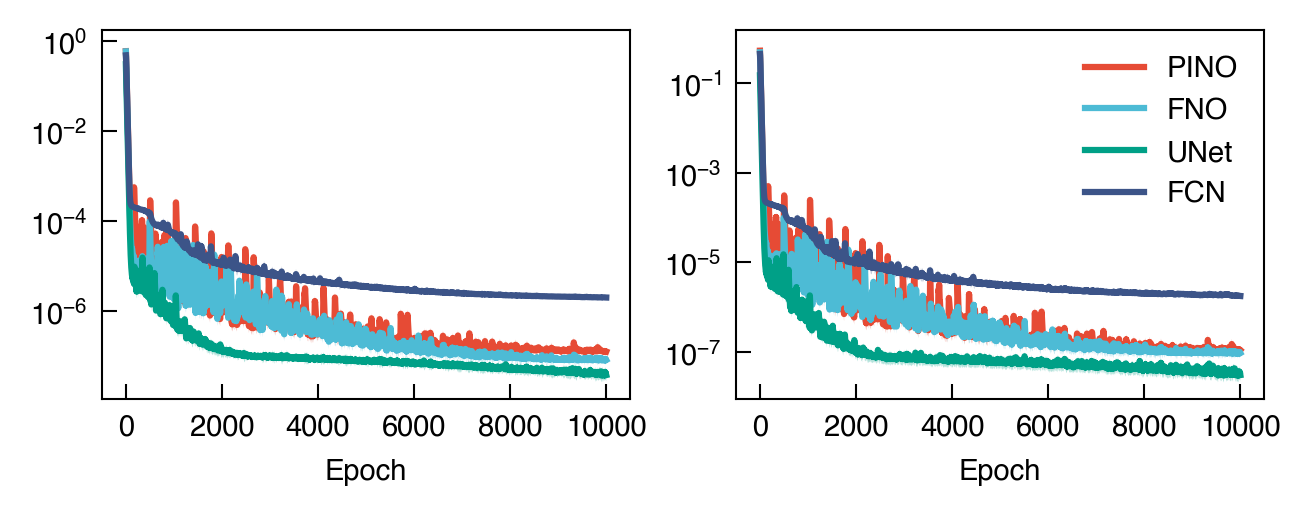

In [3]:
# read csv loss
import pandas as pd
save_dir_pino = "./corrosion1d/runs/FNO-PI/"
save_dir_fno = "./corrosion1d/runs/FNO/"
save_dir_unet = "./corrosion1d/runs/UNET/"
save_dir_fcn = "./corrosion1d/runs/FCN/"
# loss_df_fno = pd.read_csv(os.path.join(save_dir_fno, "logs.csv"))
# loss_df_pino = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))
# test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))

dirs = [
    (save_dir_pino, "PINO"),
    (save_dir_fno, "FNO"),
    (save_dir_unet, "UNet"),
    (save_dir_fcn, "FCN"),
]
import numpy as np
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci


fig, axes = plt.subplots(1, 2, figsize=(5.0, 1.6),)
for idx, (dir_path, model_name) in enumerate(dirs):
    loss_df = pd.read_csv(os.path.join(dir_path, "logs.csv"))
    
    ax = axes[0]
    # ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["TrainLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    
    ax = axes[1]
    # ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label=model_name)
    avg, ci = smooth_and_ci_ewma(loss_df["ValidLoss"].values, alpha=0.1)
    ax.plot(loss_df["Epoch"], avg, label=model_name)
    ax.fill_between(loss_df["Epoch"], avg - ci, avg + ci, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    
    ax.legend()


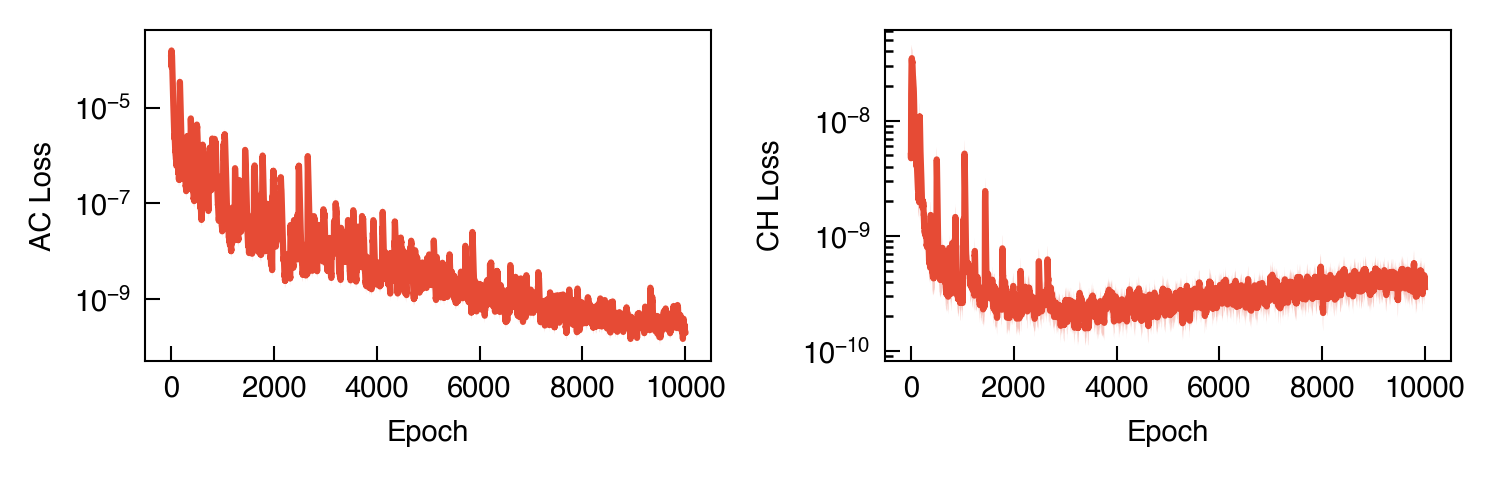

In [4]:
def smooth_and_ci_ewma(series, alpha=0.1):
    """使用指数加权移动平均，对异常值不敏感"""
    s = pd.Series(np.asarray(series, dtype=float))
    
    # 处理异常值
    s = s.replace([0, np.inf, -np.inf], np.nan)
    # s = s.fillna(method='ffill').fillna(method='bfill')
    s = s.ffill().bfill()
    
    # 指数加权移动平均
    ewm_mean = s.ewm(alpha=alpha, adjust=False).mean().to_numpy()
    ewm_std = s.ewm(alpha=alpha, adjust=False).std().to_numpy()
    
    # 限制置信区间
    ewm_std = np.nan_to_num(ewm_std)
    ci = np.minimum(1.96 * ewm_std, 0.3 * np.abs(ewm_mean))
    
    return ewm_mean, ci

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 1.6))
pino_loss_df = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))

ax = axes[0]
mean, ci = smooth_and_ci_ewma(pino_loss_df["ACLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("AC Loss")

ax = axes[1]
mean, ci = smooth_and_ci_ewma(pino_loss_df["CHLoss"].values, alpha=0.1)
ax.plot(pino_loss_df["Epoch"], mean, label="PINO")
ax.fill_between(pino_loss_df["Epoch"], mean - ci, mean + ci, alpha=0.3)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("CH Loss")

fig.tight_layout()

Text(0, 0.5, 'Test MSE Loss')

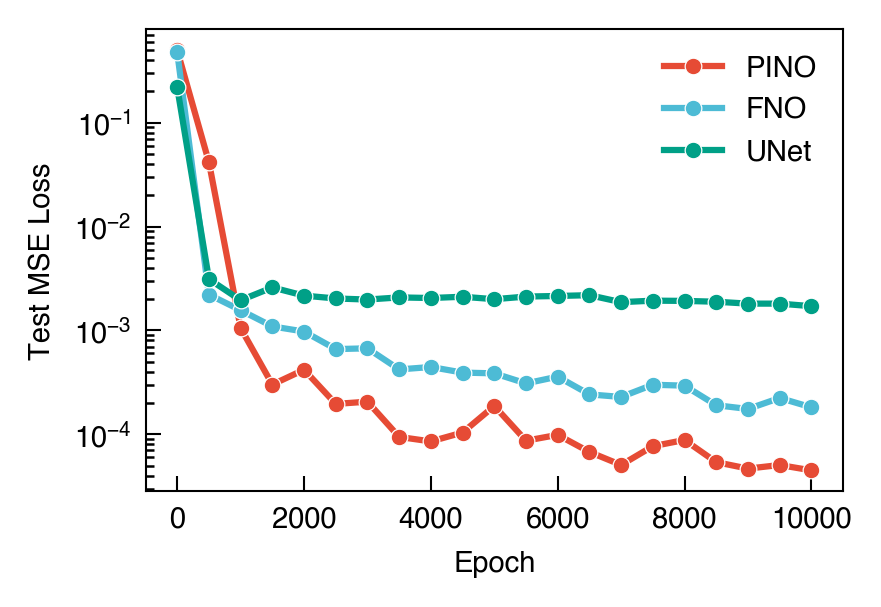

In [5]:
# test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))
# test_df_pino = pd.read_csv(os.path.join(save_dir_pino, "test_logs.csv"))

fig, ax = plt.subplots(1, 1, figsize=(3.0, 2.0))
# ax.plot(test_df_fno["Epoch"], test_df_fno["TestMSE"], label="FNO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
# ax.plot(test_df_pino["Epoch"], test_df_pino["TestMSE"], label="PINO", marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

for dir_path, model_name in dirs[:-1]:
    test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
    ax.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)
    

ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test MSE Loss")
# ax_in = ax.inset_axes([0.2, 0.2, 0.47, 0.47], xlim=(8000, 10000), ylim=(1e-5, 1e-3), yscale="log")
# for dir_path, model_name in dirs:
#     test_df = pd.read_csv(os.path.join(dir_path, "test_logs.csv"))
#     ax_in.plot(test_df["Epoch"], test_df["TestMSE"], label=model_name, marker='o', markersize=4, markeredgecolor="white", markeredgewidth=0.3)

    

# fig.tight_layout()
# print("Final FNO Test MSE:", test_df_fno["TestMSE"].values[-1])
# print("Final PINO Test MSE:", test_df_pino["TestMSE"].values[-1])

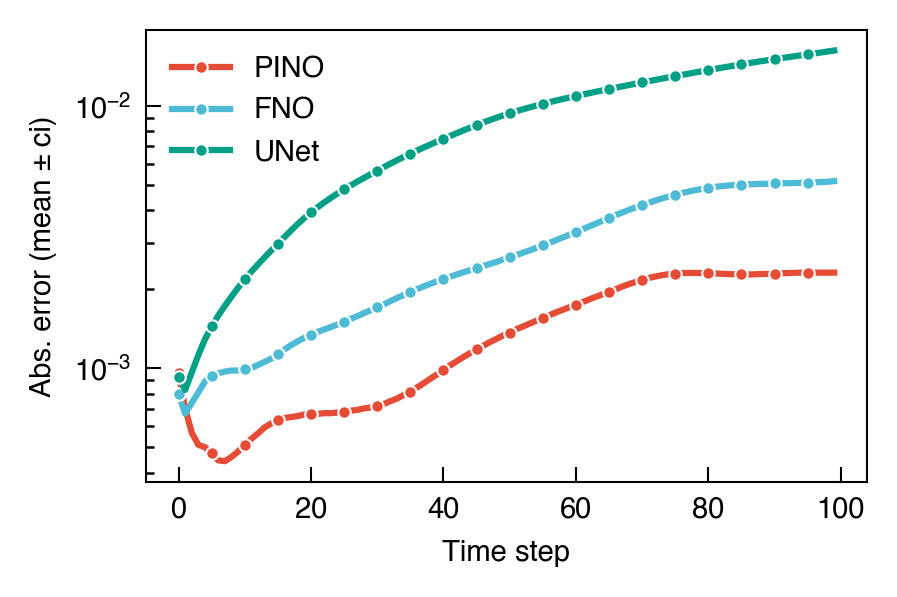

In [6]:
def plot_mean_with_std(ax, data, color, label):
    mean = jnp.mean(data, axis=0)
    std = jnp.std(data, axis=0, ddof=1)
    sem = std / jnp.sqrt(data.shape[0])
    ax.plot(mean, color=color, label=label, marker='o', markersize=3, 
            markeredgecolor="white", markevery=5, markeredgewidth=0.5)
    # ax.fill_between(
    #     jnp.arange(data.shape[1]),
    #     mean - 1.96 * sem,
    #     mean + 1.96 * sem,
    #     alpha=0.3,
    #     color=color
    # )
    

fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for dir_path, model_name in dirs[:-1]:
    test_results = jnp.load(os.path.join(dir_path, "test_results.npz"))
    y_test = test_results["y_test"]
    y_test_pred = test_results["y_test_pred"]
    error = jnp.abs(y_test - y_test_pred)
    mean_error = jnp.mean(error, axis=(2,3))
    # rel_l2 = jnp.linalg.norm(y_test - y_test_pred, axis=(2,3)) / jnp.linalg.norm(y_test, axis=(2,3))
    plot_mean_with_std(ax, mean_error, color="C"+str(dirs.index((dir_path, model_name))), label=model_name)
# plot_mean_with_std(ax, mean_error_fno, color="C0", label="FNO")
# plot_mean_with_std(ax, mean_error_pino, color="C1", label="PINO")
ax.legend()
ax.set_ylabel("Abs. error (mean \u00B1 ci)")
ax.set_yscale("log")
ax.set_xlabel("Time step")

fig.tight_layout()

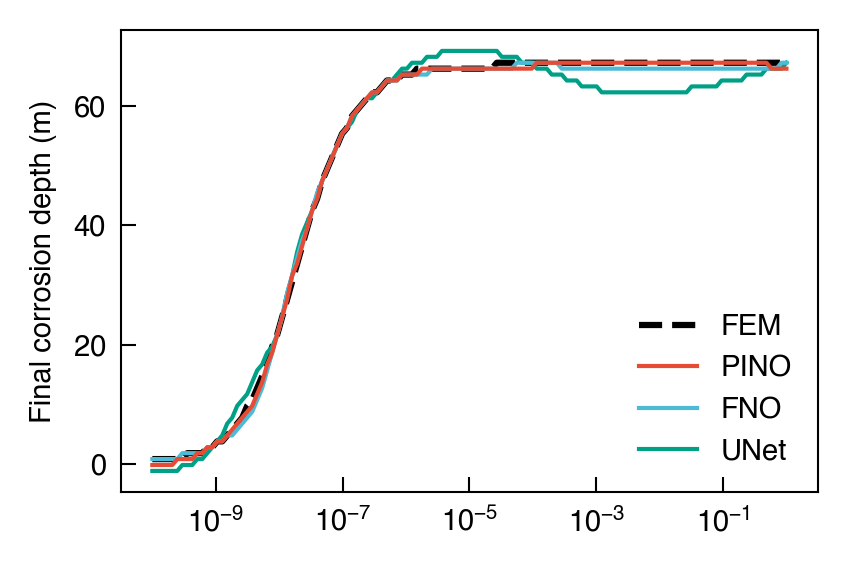

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
lps = jnp.load("./corrosion1d/data/final_corrosion_depth/Lp_values.npy")
final_corrosion_depths_fem = jnp.load("./corrosion1d/data/final_corrosion_depth/final_corrosion_depth.npy") * 1e6  # in microns
ax.plot(lps, final_corrosion_depths_fem, label="FEM", color="black", linestyle="--",)
for idx, (dir_path, model_name) in enumerate(dirs[:-1]):
    final_corrosion_depth = jnp.load(os.path.join(dir_path, "corrosion_depths.npz"))["corrosion_depths"]
    ax.plot(lps, final_corrosion_depth, label=model_name, lw=1, zorder=(len(dirs)-idx))
ax.set_xscale("log")
ax.set_ylabel("Final corrosion depth (m)")
ax.legend()
